#### **OBSERVATIONS:**

1.  The main objective of the problem statement is to determine whether the customer will churn or not based on the customer details by building the Artificial Neural Networks.

2.  We can also improve the accuracy of the model.


####   **Steps involved in this Project**

1.  Import all the necessary libraries

2.  Load the dataset

3.  Do Exploratory Data Analysis

4.  Perform the data preprocessing by performing mapping on Gender and OneHotEncoder on Geography column

5.  Divide the dataset into independent and dependent variables

6.  Divide the independent and dependent variables into training and testing data

7.  Scale the input data in one range

8.  Compute the class weights to address the imbalance and improve it

9.  Build the improved ANN Model

10. Compile the Model

11. Add the callbacks as a parameter to the model for improving the accuracy of the model

12. Train the Model

13. Evaluate the performance of the Model

14. Plot the Accuracy and the loss of the model

15. Make the prediction, confusion matrix and classification report

16. Test a sample test data for checking whether the customer will leave or stay in the bank

#### **Step 1: Import all the necessary libraries**

In [162]:
import  numpy             as  np
import  pandas            as  pd
import  matplotlib.pyplot as  plt
import  seaborn           as  sns

from    sklearn.utils.class_weight import compute_class_weight
from    sklearn.compose            import ColumnTransformer
from    sklearn.model_selection    import train_test_split
from    sklearn.preprocessing      import StandardScaler
from    sklearn.preprocessing      import LabelEncoder

from    tensorflow.keras.models    import Sequential
from    tensorflow.keras.layers    import Dense, Dropout,BatchNormalization
from    tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#### **OBSERVATIONS:**

1.  BatchNormalization ------>  It is done to stabilize and speed up the neural network training.

2.  EarlyStopping -------->

      (a.)  EarlyStopping is done to stop the model training early when we see that there is no improvement in the performance of the model

      (b.)  It is done to prevent the overfitting.

3.  ReduceLROnPlateau ------->

      (a.)  It is done to reduce the learning rate when there is no improvement in model performance.

      (b.)  It is done to stop the training so that the model will learn accurately.

#### **Step 2: Load the dataset**

In [163]:
#### Load the dataset
df = pd.read_csv('/content/Churn_Modelling.csv')

df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


#### **OBSERVATIONS:**

1.  The above dataset explains the details of the customer with details such as

    (a.)  RowNumber ---------->  Row number of each customer

    (b.)  CustomerId --------->  Id of each customer

    (c.)  Surname   ---------->  Title of each customer

    (d.)  CreditScore -------->  Credit score of each customer

    (e.)  Geography ---------->  Geographical location of each customer

    (f.)  Gender  ------------>  Gender of the customer whether male/female

    (g.)  Age     ----------->   Age of the customer

    (h.)  Tenure  ------------>  Tenure period of the customer

    (i)   Balance  ----------->   Balance Amount of the customer

    (j)  NumOfProducts ------->  Number of products for each customer

    (k)  HasCrCard ----------->   whether the person has CreditCard or not

    (l)  IsActiveMember ------->  whether the customer is an active member or not

    (m)  EstimatedSalary  ------>   Estimated Salary for each customer

    (n)  Exited ---------------->  determines whether the customer will leave the bank or not

#### **Step 3: Do Exploratory Data Analysis**

In [164]:
#### get the first five rows of the dataset
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [165]:
#### get the last five rows of the dataset
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [166]:
#### get the length of the dataset
print("Length of the dataset is:", len(df))

Length of the dataset is: 10000


In [167]:
#### get the shape of the dataset
print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (10000, 14)


In [168]:
#### get the information about the columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [169]:
#### get the descriptive statistical summary about the columns in the dataset
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


#### **OBSERVATIONS:**

1.  The above dataset explains about the summary information for each numerical column used in the dataset.

#### **Step 4: Perform the data preprocessing**

In [170]:
#### check for the null records in the dataset
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


#### **OBERVATIONS:**

1.  There are no NULL records in the dataset.

In [171]:
#### To check for the duplicate records in the dataset
df[df.duplicated()]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


#### **OBSERVATIONS:**

1.  There are no duplicate records in the dataset.

In [172]:
#### perform the encoding on Gender and Geography column
cols = ['Geography', 'Gender']

#### create an object for label encoder
label = LabelEncoder()

for x in cols:
  df[x] = label.fit_transform(df[x])

In [173]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,1,1,42,3,75075.31,2,1,0,92888.52,1


#### **OBSERVATIONS:**

1.  After performing label encoding, all the column values of Geography and Gender has been converted to their proper numerical values.

In [174]:
#### Remove all the unnecessary columns from the dataset
df.drop(columns=['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [175]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


#### **OBSERVATIONS:**

1.  All the unnecessary input features have been removed from the dataset.

2.  All the independent input features are numerical in nature and is now ready for the training.

#### **Step 5: Divide the dataset into independent and dependent variables**

In [176]:
#### independent features
X = df.drop(columns=['Exited'],axis=1)
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64
9996,516,0,1,35,10,57369.61,1,1,1,101699.77
9997,709,0,0,36,7,0.00,1,0,1,42085.58
9998,772,1,1,42,3,75075.31,2,1,0,92888.52


In [177]:
#### dependent features
Y = df['Exited']
Y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


#### **OBSERVATIONS:**

1.  The entire dataset is divided into independent and dependent features.

#### **Step 6: Divide the independent and dependent variables into training and testing data**

In [178]:
from sklearn.model_selection import train_test_split

#### divide the dataset into training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [179]:
X_train

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
2151,753,0,1,57,7,0.00,1,1,0,159475.08
8392,739,1,1,32,3,102128.27,1,1,0,63981.37
5006,755,1,0,37,0,113865.23,2,1,1,117396.25
4117,561,0,1,37,5,0.00,2,1,0,83093.25
7182,692,1,1,49,6,110540.43,2,0,1,107472.99
...,...,...,...,...,...,...,...,...,...,...
4555,688,2,0,35,6,0.00,1,1,0,25488.43
4644,712,2,1,74,5,0.00,2,0,0,151425.82
8942,667,0,0,37,9,71786.90,2,1,1,67734.79
2935,687,2,1,35,8,100988.39,2,1,0,22247.27


In [180]:
X_test

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
5702,585,0,1,36,7,0.00,2,1,0,94283.09
3667,525,1,1,33,4,131023.76,2,0,0,55072.93
1617,557,2,0,40,4,0.00,2,0,1,105433.53
5673,639,2,1,34,5,139393.19,2,0,0,33950.08
4272,640,2,0,34,3,77826.80,1,1,1,168544.85
...,...,...,...,...,...,...,...,...,...,...
5768,674,0,1,36,2,154525.70,1,0,1,27468.72
833,634,1,1,37,3,111432.77,2,1,1,167032.49
9719,516,1,0,47,9,128298.74,1,0,0,149614.17
2776,689,0,1,39,7,0.00,2,0,0,14917.09


In [181]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (8000, 10)
Shape of the input testing  data is: (2000, 10)


In [182]:
Y_train

,Exited
2151,1
8392,1
5006,0
4117,0
7182,0
...,...
4555,1
4644,0
8942,0
2935,0


In [183]:
Y_test

,Exited
5702,0
3667,0
1617,0
5673,0
4272,0
...,...
5768,0
833,0
9719,1
2776,0


In [184]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (8000,)
Shape of the output testing  data is: (2000,)


#### **OBSERVATIONS:**

1.  The independent and dependent features are divided into

    (a.)  80 % of the training data

    (b.)  20 % of the testing data

#### **Step 7: Scale the input data in one range**

In [185]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [186]:
X_train_scaled

array([[ 1.058568  , -0.90593285,  0.90750738, ...,  0.64104192,
        -1.030206  ,  1.04208392],
       [ 0.91362605,  0.30016846,  0.90750738, ...,  0.64104192,
        -1.030206  , -0.62355635],
       [ 1.07927399,  0.30016846, -1.10191942, ...,  0.64104192,
         0.97067965,  0.30812779],
       ...,
       [ 0.16821031, -0.90593285, -1.10191942, ...,  0.64104192,
         0.97067965, -0.55808767],
       [ 0.37527024,  1.50626978,  0.90750738, ...,  0.64104192,
        -1.030206  , -1.35149956],
       [ 1.56586482,  1.50626978,  0.90750738, ..., -1.55996038,
         0.97067965, -1.02692216]])

In [187]:
X_test_scaled

array([[-0.68073539, -0.90593285,  0.90750738, ...,  0.64104192,
        -1.030206  , -0.09502138],
       [-1.30191518,  0.30016846,  0.90750738, ..., -1.55996038,
        -1.030206  , -0.778941  ],
       [-0.97061929,  1.50626978, -1.10191942, ..., -1.55996038,
         0.97067965,  0.09946914],
       ...,
       [-1.39509214,  0.30016846, -1.10191942, ..., -1.55996038,
        -1.030206  ,  0.8700859 ],
       [ 0.39597623, -0.90593285,  0.90750738, ..., -1.55996038,
        -1.030206  , -1.47935555],
       [ 1.02750901, -0.90593285,  0.90750738, ...,  0.64104192,
        -1.030206  , -0.49531855]])

#### **OBSERVATIONS:**

1.  The input features has been scaled in one input range between -1 to 1.

#### **Step 8: Compute the class weights to address the imbalance and improve it**

In [188]:
Y_train.value_counts()

,count
Exited,
0,6370
1,1630


In [189]:
Y_test.value_counts()

,count
Exited,
0,1593
1,407


#### **OBSERVATIONS:**

1.  Here we can see that Exited class '0' is much higher in number than Exited class '1' in both the training and testing data.

2.  So for this class imbalancing needs to be addressed.

In [190]:
#### To address the imbalancing, compute the weights of all the unique classes

#### get all the unique class
unique_class=np.unique(Y_train)
print(unique_class)

#### compute the weights of all the unique classes
from sklearn.utils.class_weight import compute_class_weight
class_weight_values = compute_class_weight(
    class_weight = 'balanced'                                 ,
    classes      = unique_class                               ,
    y            = Y_train
)

print(class_weight_values)

#### create a dictionary that maps each class to the class weights
class_weight_ans = {int(x):y for x,y in zip(unique_class,class_weight_values)}
print(class_weight_ans)

[0 1]
[0.62794349 2.45398773]
{0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}


#### **OBSERVATIONS:**

1.  Class weights are computed for each unique class inorder to tell the ANN Model to give more importance to the minority class during model training.

In [191]:
Y_train.value_counts()

,count
Exited,
0,6370
1,1630


In [192]:
#### Resolve all the imbalanced class weights
from imblearn.over_sampling import SMOTE
#### create an instance of SMOTE
smote = SMOTE(random_state=42)
#### using the instance of SMOTE, transform the training data
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train_scaled, Y_train)

In [193]:
X_train_resampled

array([[ 1.058568  , -0.90593285,  0.90750738, ...,  0.64104192,
        -1.030206  ,  1.04208392],
       [ 0.91362605,  0.30016846,  0.90750738, ...,  0.64104192,
        -1.030206  , -0.62355635],
       [ 1.07927399,  0.30016846, -1.10191942, ...,  0.64104192,
         0.97067965,  0.30812779],
       ...,
       [ 0.13562526, -0.90593285, -1.10191942, ...,  0.64104192,
         0.97067965,  0.75273716],
       [ 0.64164126,  0.30016846, -1.10191942, ...,  0.64104192,
        -1.030206  ,  0.54388296],
       [-0.00429179,  0.30016846,  0.90750738, ...,  0.64104192,
        -1.030206  , -0.60311758]])

In [194]:
Y_train_resampled

,Exited
0,1
1,1
2,0
3,0
4,0
...,...
12735,1
12736,1
12737,1
12738,1


In [195]:
Y_train_resampled.value_counts()

,count
Exited,
1,6370
0,6370


#### **OBSERVATIONS:**

1.  After applying SMOTE technique, we can see that total number of records in Exited Class 1 and Exited Class 2 is the same.

#### **Step 9: Build the improved ANN Model**

In [196]:
#### Construct the ANN Model for Customer Churn Prediction
model = Sequential([
    #### construct the first dense layer
    Dense(64,activation='relu',input_dim=X_train_resampled.shape[1])                          ,
    #### perform BatchNormalization
    BatchNormalization()                                                                      ,
    #### Add a dropout layer on the top of the dense layer
    Dropout(0.25)                                                                             ,

    #### construct the second dense layer
    Dense(32,activation='relu')                                                               ,
    #### perform BatchNormalization
    BatchNormalization()                                                                      ,
    #### Add a dropout layer on the top of the dense layer
    Dropout(0.15)                                                                             ,

    #### construct the third dense layer
    Dense(16,activation='relu')                                                               ,
    #### perform Batch Normalization
    BatchNormalization()                                                                      ,
    #### Add a dropout layer on the top of the dense layer
    Dropout(0.1)                                                                              ,

    #### construct the output layer
    Dense(1,activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [197]:
model

<Sequential name=sequential_3, built=True>

#### **OBSERVATIONS:**

1.  The Sequential model is created with the following layers:--

    (a.)  First Hidden layer

          (i) Input_dim ----> It considers the input as total number of input features.

          (ii)  activation = 'relu' -----> The activation function used is 'relu' inorder to increase the non-linearity of the image.

          (iii)  It considers 64 neurons in the first hidden layer.

          (iv)  BatchNormalization --------> It is done to stabilize and speed up the training process.

          (v)  Then dropout layer has been added that reduces 25 % of the neuron from the first hidden layer.


    (b.)  Second Hidden layer

          (i)  activation = 'relu' -----> The activation function used is 'relu' inorder to increase the non-linearity of the image.

          (iii)  It considers 32 neurons in the second hidden layer.

          (iv)  BatchNormalization --------> It is done to stabilize and speed up the training process.

          (v)  Then dropout layer has been added that reduces 15 % of the neuron from the second hidden layer.


    (c.)  Third Hidden layer

          (i)  activation = 'relu' -----> The activation function used is 'relu' inorder to increase the non-linearity of the image.

          (iii)  It considers 16 neurons in the third hidden layer.

          (iv)  BatchNormalization --------> It is done to stabilize and speed up the training process.

          (v)  Then dropout layer has been added that reduces 10 % of the neuron from the third hidden layer.

    (d.)  Final Output Layer

          (i)  The final output layer has been constructed with one hidden neuron in it.

          (ii) The sigmoid activation function has been applied on it to solve the binary classification problem

#### **Step 10: Compile the Model**

In [198]:
#### Compile the model
model.compile(
    optimizer = 'adam'                        ,
    loss      = 'binary_crossentropy'         ,
    metrics   = ['accuracy']
)

#### **OBSERVATIONS:**

1.  The model has been ready for training with the following parameters:---  

      (a.)  optimizer = 'adam'

          (i)  It is an optimizer that updates the weights during the backpropogation

          (ii)  It reduces the noise and makes the learning rate as dynamic.


      (b.) loss = 'binary_crossentropy'

          (i)  It is the loss function that is used to solve the binary classification problem.


      (c.)  metrics = ['accuracy']

          (i)  It is used to evaluate the performance of the model.

In [199]:
#### get the summary of the model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,553 (13.88 KB)

 Non-trainable params: 224 (896.00 B)

#### **Step 11: Add the callbacks as a parameter to the model for improving the accuracy of the model**

In [200]:
#### create the callback parameter for EarlyStopping
er = EarlyStopping(
    monitor                =              'val_loss'                                                        ,
    patience               =                8                                                               ,
    restore_best_weights   =               True                                                             ,
    verbose                =                1
)


#### create a callback parameter for ReduceLROnPlateau
rlr = ReduceLROnPlateau(
    monitor                 =             'val_loss'                                                        ,
    factor                  =               0.5                                                             ,
    patience                =               5                                                               ,
    verbose                 =               1
)

#### **OBSERVATIONS:**

1.  Here Early Stopping is used

    (i)  to stop the training when we see that there is no improvement in the performance of the model

    (ii)  It is done to prevent the overfitting


2.   ReduceLROnPlataeu is used

    (i) to reduce the learning rate when there is no improvement in the performance of the model.

#### **Step 12: Train the Model**

In [201]:
#### train the model
history = model.fit(
    X_train_resampled                                         ,
    Y_train_resampled                                         ,
    validation_split          =         0.15                  ,
    epochs                    =         100                   ,
    batch_size                =         32                    ,
    callbacks                 =         [er,rlr]              ,
    verbose                   =             2

)

Epoch 1/100
339/339 - 8s - 25ms/step - accuracy: 0.6552 - loss: 0.6353 - val_accuracy: 0.6122 - val_loss: 0.6737 - learning_rate: 0.0010
Epoch 2/100
339/339 - 1s - 4ms/step - accuracy: 0.7256 - loss: 0.5407 - val_accuracy: 0.6918 - val_loss: 0.6110 - learning_rate: 0.0010
Epoch 3/100
339/339 - 1s - 3ms/step - accuracy: 0.7528 - loss: 0.5063 - val_accuracy: 0.7096 - val_loss: 0.5831 - learning_rate: 0.0010
Epoch 4/100
339/339 - 1s - 3ms/step - accuracy: 0.7625 - loss: 0.4890 - val_accuracy: 0.7431 - val_loss: 0.5437 - learning_rate: 0.0010
Epoch 5/100
339/339 - 1s - 3ms/step - accuracy: 0.7691 - loss: 0.4847 - val_accuracy: 0.7033 - val_loss: 0.5659 - learning_rate: 0.0010
Epoch 6/100
339/339 - 1s - 3ms/step - accuracy: 0.7737 - loss: 0.4744 - val_accuracy: 0.7551 - val_loss: 0.5138 - learning_rate: 0.0010
Epoch 7/100
339/339 - 1s - 3ms/step - accuracy: 0.7800 - loss: 0.4635 - val_accuracy: 0.7211 - val_loss: 0.5664 - learning_rate: 0.0010
Epoch 8/100
339/339 - 1s - 3ms/step - accuracy:

In [202]:
history

#### **OBSERVATIONS:**

1.  After model training we came to the conclusion that

      (a.)  the training accuracy and the validation accuracy of the model has increased.

      (b.)  but the training and the validation loss of the model has reduced.

2.  The  accuracy of the model has improved a lot and the loss function has reduced

#### **Step 13: Evaluate the performance of the Model**

In [203]:
#### Calculate the training
train_loss, train_acc = model.evaluate(X_train_resampled, Y_train_resampled, verbose=0)

print(f"\nTrain loss: {train_loss:.4f}, Train acc: {train_acc:.4f}")


Train loss: 0.3829, Train acc: 0.8242


In [204]:
#### Calculate the testing
test_loss, test_acc = model.evaluate(X_test_scaled, Y_test, verbose=0)

print(f"\nTest loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")


Test loss: 0.4037, Test acc: 0.8135


#### **OBSERVATIONS:**

1.  After model evaluation, we came to the conclusion that

      (a.)  The training and testing accuracy of the model is very high.

      (b.)  The training and testing loss of the model is very low.


2.  So the model is working fine.

#### **Step 14: Plot the Accuracy and the loss of the model**

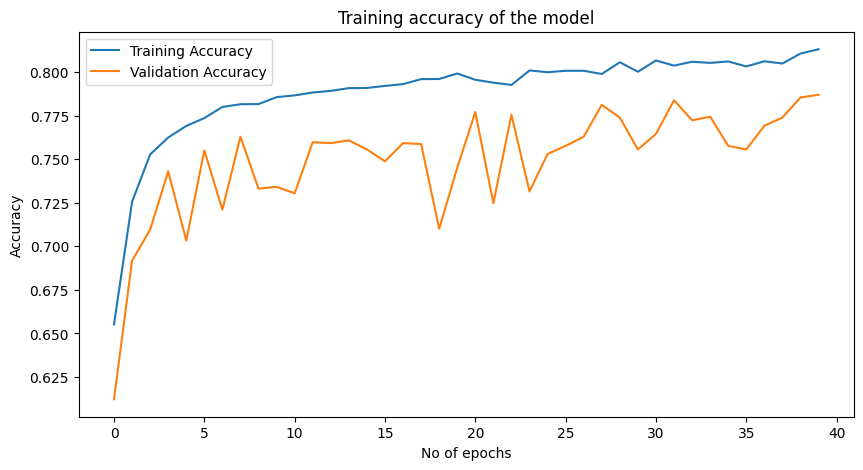

In [205]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label = 'Training Accuracy')

plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

plt.title('Training accuracy of the model')

plt.xlabel('No of epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

#### **OBSERVATIONS:**

1.  With the increase in the number of epochs, the training accuracy of the model increases.

2.   But the Validaton accuracy of the model remains constant.

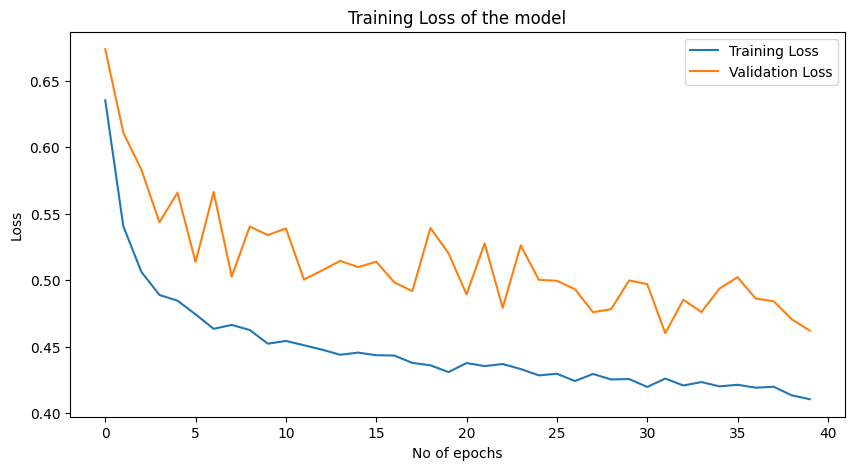

In [206]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label = 'Training Loss')

plt.plot(history.history['val_loss'], label = 'Validation Loss')

plt.title('Training Loss of the model')

plt.xlabel('No of epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()

#### **OBSERVATIONS:**

1.  With the increase in the number of epochs, the training and the Validation loss of the model decreases continuously.

#### **Step 15: Make the prediction, confusion matrix and classification report**

In [207]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [208]:
#### prediction
Y_pred = model.predict(X_test_scaled).ravel()
Y_pred = (Y_pred > 0.5).astype(int)
Y_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([0, 0, 0, ..., 1, 0, 0])

In [209]:
ac = accuracy_score(Y_test,Y_pred)*100.0

In [210]:
rocscore = roc_auc_score(Y_test,Y_pred)

In [211]:
cm = confusion_matrix(Y_test, Y_pred)

In [212]:
cr = classification_report(Y_test, Y_pred, digits=4)

In [213]:
print("\nAccuracy  of the model is:\n", ac)
print("\nROC Score of the model is:\n", rocscore)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", cr)


Accuracy  of the model is:
 81.35

ROC Score of the model is:
 0.7631090258208902

Confusion matrix:
 [[1351  242]
 [ 131  276]]

Classification report:
               precision    recall  f1-score   support

           0     0.9116    0.8481    0.8787      1593
           1     0.5328    0.6781    0.5968       407

    accuracy                         0.8135      2000
   macro avg     0.7222    0.7631    0.7377      2000
weighted avg     0.8345    0.8135    0.8213      2000



#### **OBSERVATIONS:**

1. The accuracy score of the model is very high. So the model is working fine for Customer Churn dataset.

#### **Step 16: Test a sample test data for checking whether the customer will leave or stay in the bank**

In [214]:
import pandas as pd
import numpy as np

# -------------------------------
# 1. Create sample customer input
# -------------------------------
sample = {
    'CreditScore': 650,
    'Age': 40,
    'Tenure': 3,
    'Balance': 60000.0,
    'NumOfProducts': 1,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000.0,
    'Geography': 'France',
    'Gender': 'Male'
}


sample_df = pd.DataFrame([sample])
print("Original Sample Input:\n", sample_df)

# -------------------------------
# 2. Encode Gender
# -------------------------------
sample_df['Gender'] = sample_df['Gender'].map({'Female': 0, 'Male': 1}).astype(int)

# -------------------------------
# 3. One-hot encode Geography
#    (same logic as training)
# -------------------------------
sample_df = pd.get_dummies(sample_df, columns=['Geography'], drop_first=True)

# -------------------------------
# 4. Ensure all training columns exist
# -------------------------------
for col in X_train.columns:
    if col not in sample_df.columns:
        sample_df[col] = 0

# -------------------------------
# 5. Reorder columns exactly
# -------------------------------
sample_df = sample_df[X_train.columns]

print("\nProcessed Sample Input:\n", sample_df)

# -------------------------------
# 6. Apply scaling
# -------------------------------
sample_scaled = sc.transform(sample_df)

# -------------------------------
# 7. Predict churn
# -------------------------------
y_prob = model.predict(sample_scaled)[0][0]
y_pred = int(y_prob >= 0.5)

# -------------------------------
# 8. Output result
# -------------------------------
print(f"\nPredicted Probability of Churn: {y_prob:.4f}")

if y_pred == 1:
    print("Prediction: Customer will LEAVE the bank ❌")
else:
    print("Prediction: Customer will STAY in the bank ✅")

Original Sample Input:
    CreditScore  Age  Tenure  Balance  NumOfProducts  HasCrCard  \
0          650   40       3  60000.0              1          1   

   IsActiveMember  EstimatedSalary Geography Gender  
0               1          50000.0    France   Male  

Processed Sample Input:
    CreditScore  Geography  Gender  Age  Tenure  Balance  NumOfProducts  \
0          650          0       1   40       3  60000.0              1   

   HasCrCard  IsActiveMember  EstimatedSalary  
0          1               1          50000.0  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Predicted Probability of Churn: 0.2483
Prediction: Customer will STAY in the bank ✅
